## **Timeseries Market Trend Extraction Model**

In [13]:
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os
import pandas as pd
import seaborn as sns

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

In [7]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from pipeline.feature_pipeline import PROCESSED_DATA_FILE

current_working_dir = os.getcwd()

if os.path.basename(current_working_dir) == "layers":
    project_root = os.path.abspath(os.path.join(current_working_dir, ".."))
else:
    project_root = current_working_dir

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Project root added to sys.path: {project_root}")

print(f"Project root added to sys.path: {project_root}")

DATA_DIR = os.path.join(project_root, "data")
PROCESSED_DATA_FILE = os.path.join(DATA_DIR, "market_features.parquet")

try:
    market_data_df = pd.read_parquet(PROCESSED_DATA_FILE)
    print(F"Successfully loaded processed data from {PROCESSED_DATA_FILE}")
except FileNotFoundError:
    print(f"Processed data file not found at {PROCESSED_DATA_FILE}")
    print("Please ensure the feature pipeline in 'pipeline/feature_pipeline.py' has been added to generate the data.")
    market_data_df = pd.DataFrame()

print(market_data_df.head())

Project root added to sys.path: /Users/raoabdul/Documents/Development/Trading-Bot-Algo
Project root added to sys.path: /Users/raoabdul/Documents/Development/Trading-Bot-Algo
Successfully loaded processed data from /Users/raoabdul/Documents/Development/Trading-Bot-Algo/data/market_features.parquet
                   datetime       close        high         low        open  \
0 2026-01-09 14:43:00+00:00  258.299988  258.480011  258.029999  258.070007   
1 2026-01-09 14:44:00+00:00  258.290009  258.290009  258.230011  258.250000   
2 2026-01-09 14:45:00+00:00  258.105011  258.299988  258.040009  258.125000   
3 2026-01-09 14:46:00+00:00  258.075012  258.320007  257.980011  258.135010   
4 2026-01-09 14:47:00+00:00  257.839996  258.149994  257.839996  258.075012   

   volume  log_return  simple_return  rolling_mean  rolling_std  \
0  121358    0.000988       0.000988    258.604645     0.680482   
1   75511   -0.000039      -0.000039    258.534653     0.656774   
2   91820   -0.000716     

In [8]:
print(market_data_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377 entries, 0 to 376
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   datetime            377 non-null    datetime64[ns, UTC]
 1   close               377 non-null    float64            
 2   high                377 non-null    float64            
 3   low                 377 non-null    float64            
 4   open                377 non-null    float64            
 5   volume              377 non-null    int64              
 6   log_return          377 non-null    float64            
 7   simple_return       377 non-null    float64            
 8   rolling_mean        377 non-null    float64            
 9   rolling_std         377 non-null    float64            
 10  rolling_zscore      377 non-null    float64            
 11  rolling_volatility  376 non-null    float64            
 12  price_range         377 non-null    

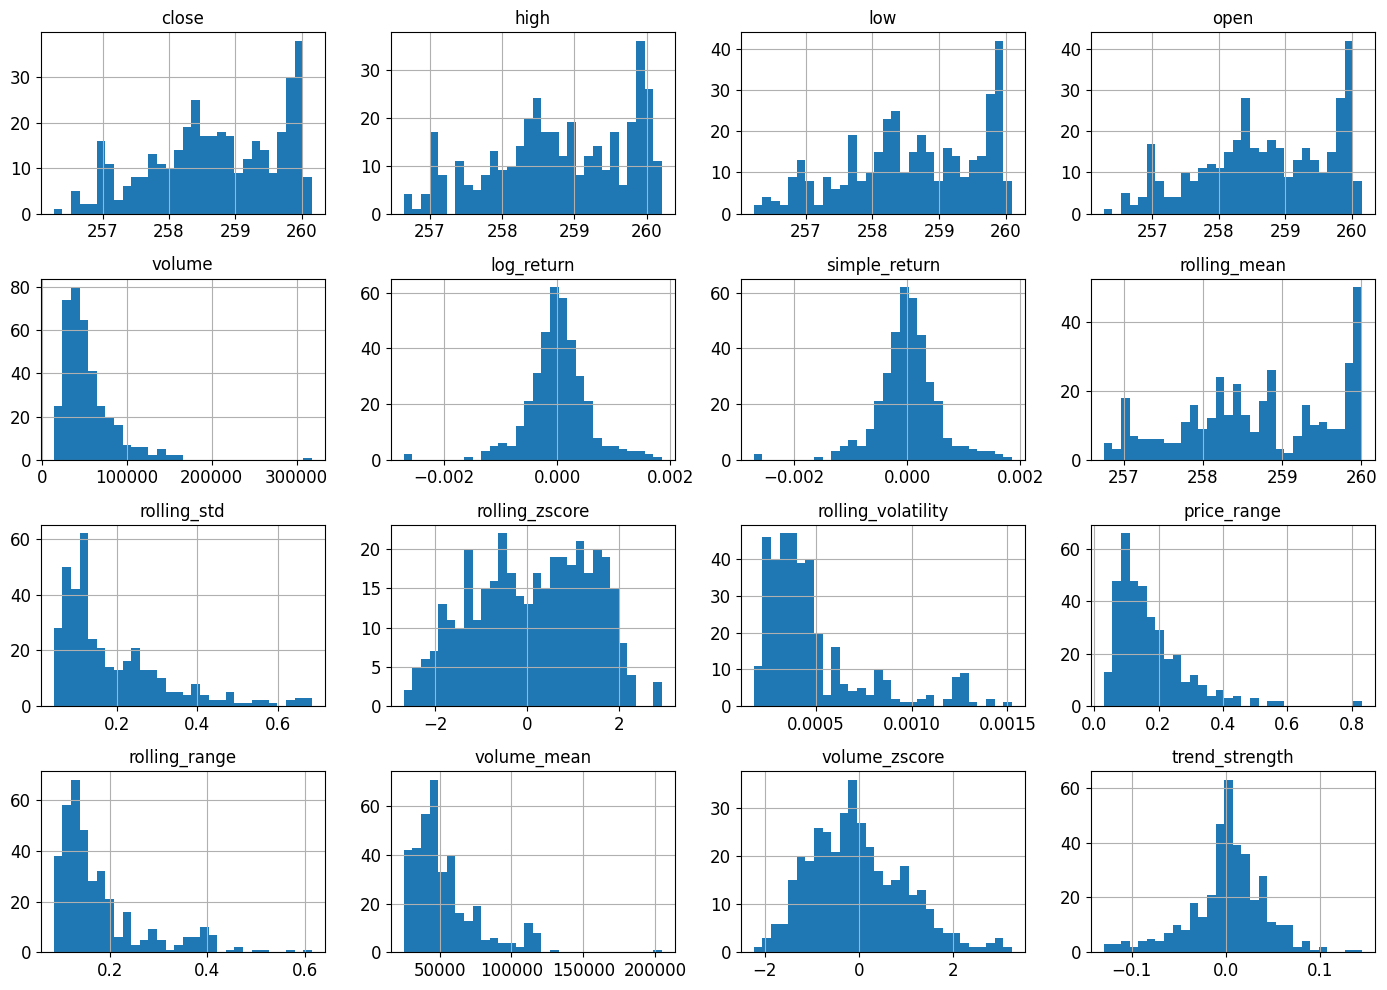

In [12]:
numeric_only_df = market_data_df.select_dtypes(include=np.number)
numeric_only_df.hist(figsize=(14,10), bins=30)
plt.tight_layout()
plt.show()

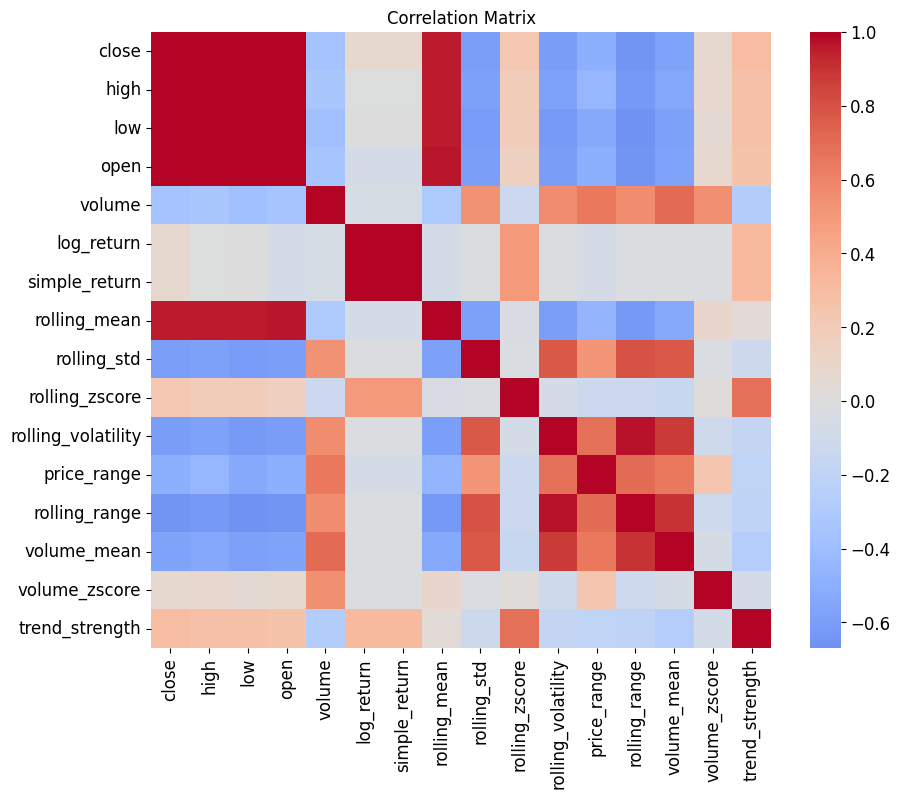

In [14]:
# Correlation matrix
corr = market_data_df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()